# Data clustering  using any decision tree Clustering algorithm for BI

In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Step 1: Load your data
df = pd.read_csv('Mall_Customers.csv')
df.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


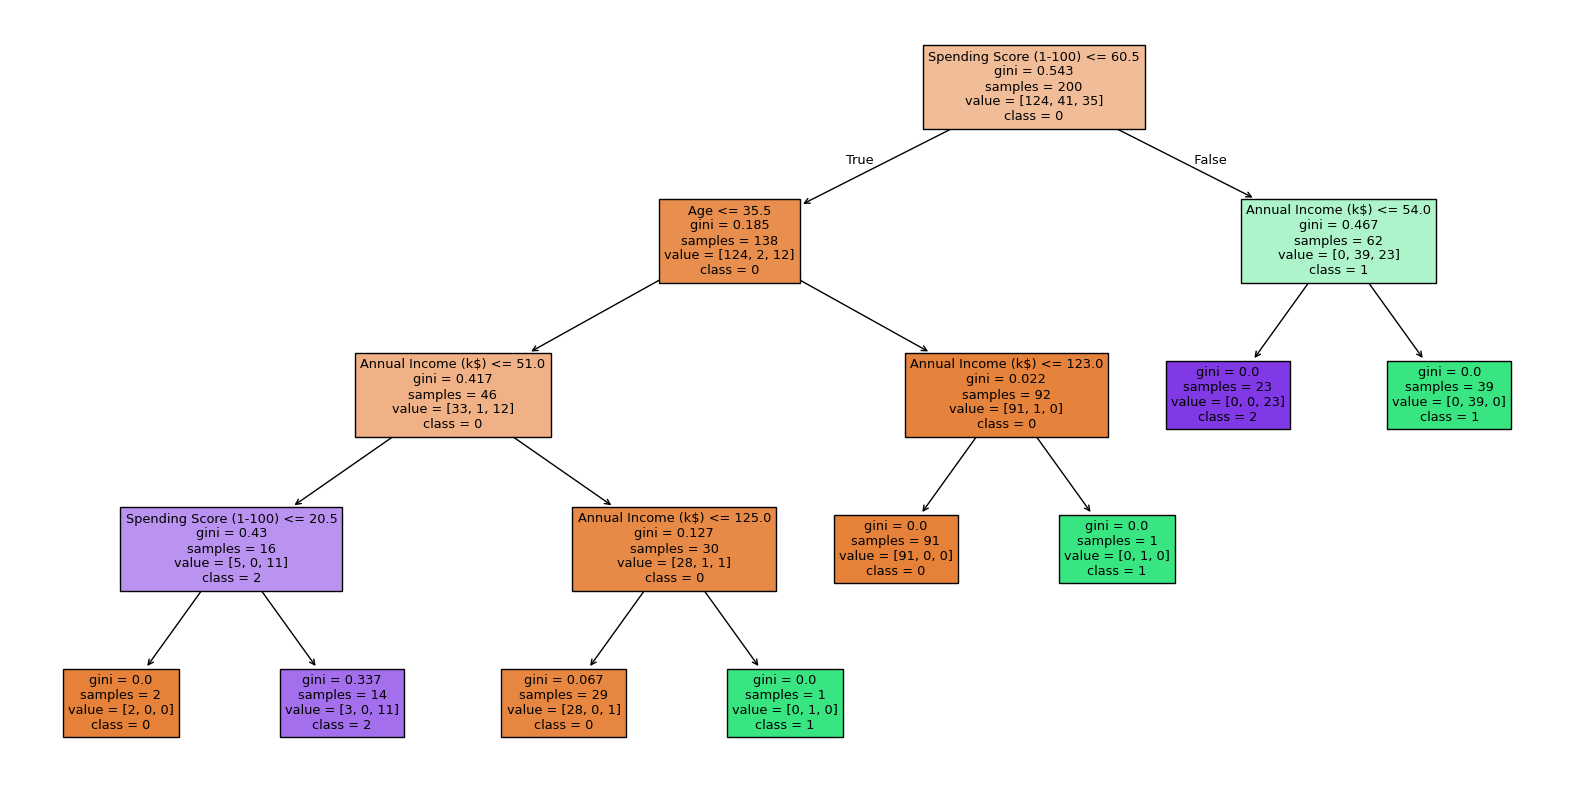

In [5]:
# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# Feature selection
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Decision Tree training
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, df['Cluster'])

# Visualize Decision Tree
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, class_names=[str(i) for i in tree.classes_], filled=True)
plt.show()